# Backbone ablation

**Backbones**
- `resnet50` — ImageNet-pretrained ResNet-50.
- `resnet50-arctic` — ResNet-50 initialized from the ARCTIC checkpoint instead of ImageNet.
- `resnet101` — deeper ResNet.
- `mobilenet_v3_l` — efficient CNN (large).
- `convnext_l` — modern CNN (large).
- `mobilevit_s` — hybrid CNN/ViT (small).
- `swinv2_tiny` — Swin Transformer V2 (tiny).
- `swin_tiny` — Swin Transformer V1 (tiny).
- `wave_vit_s` — wavelet vision transformer (small).

**Evaluation regimes**
- **Fine-tuned** — datasets seen in the training mix: `arctic`, `assembly`.
- **Zero-shot** — held-out, unseen cameras/scenes: `h2o`, `epic_handkps`, `egoexo`.

**Metrics** (lower is better)
- `mpjpe` — root-aligned MPJPE, mm. Primary 3D accuracy metric.
- `mrrpe` — relative root position error between the two hands, mm.
- `pix_err` — per-joint 2D error in the 224px patch, px.

> Per-sample `pix_err` is capped at 316 px (the patch diagonal) and `mrrpe` at 600 mm in `eval.py`,
> so the zero-shot camera-translation blow-ups can no longer dominate the averages.

## Understanding the metrics

`mpjpe` and `mrrpe` are computed in `src/metrics.py` over the 21 MANO hand joints
(joint 0 = wrist/root), in millimeters, lower is better; `pix_err` is a 2D
error in pixels.

### `mpjpe` - Root Aligned Mean Per-Joint Position Error
Average Euclidean distance between predicted and ground truth 3D joints, meaned over the 21
joints, after translating both hands such that the wrist sits at the origin. This
removes the hand's absolute camera position and measures the articulated pose
plus its global orientation.

### `mrrpe` - Mean Relative-Root Position Error (Right vs Left)
Measures the two hands' placement relative to each other (the error in the
right minus left wrist displacement vector). It requires the predicted camera translation
to be roughly correct, which is why it is the most fragile zero-shot (it blows up
on unseen cameras). It is only defined when both hands are present.

### `pix_err` - 2D pixel error (224px patch)
Per-joint Euclidean distance between predicted and GT 2D keypoints in the 224×224 patch.
Like `mrrpe` it flows through the predicted camera, so it also blows up on unseen cameras.

| Metric | Removes | Measures | Most sensitive to |
|---|---|---|---|
| `mrrpe` | common global offset only | inter-hand 3D placement | camera translation |
| `mpjpe` | per-hand translation | pose + global orientation | wrist orientation + articulation |
| `pix_err` | nothing (absolute 2D) | reprojected 2D placement | camera translation |

`mpjpe` transfers across cameras and is the fair zero-shot accuracy number. The absolute
placement metrics (`mrrpe`, `pix_err`) are driven by the camera translation head, which does
not transfer to unseen cameras at this data scale and can blow up by orders of magnitude.

In [235]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

candidates = [Path.cwd() / "results" / "ablation.csv", Path.cwd().parent / "results" / "ablation.csv"]
csv_path = next((p for p in candidates if p.exists()), candidates[0])
df = pd.read_csv(csv_path)

FINETUNED = {"arctic", "assembly"} 
df["regime"] = df["dataset"].map(lambda d: "Fine-tuned" if d in FINETUNED else "Zero-shot")
df["units"] = df["metric"].map({"mpjpe": "mm", "mrrpe": "mm", "pix_err": "px"})

BACKBONE_ORDER = ["resnet50", "resnet50-arctic", "resnet101", "mobilenet_v3_l", "convnext_l", "mobilevit_s", "swinv2_tiny", "swin_tiny", "wave_vit_s"]
DATASET_ORDER = ["arctic", "assembly", "h2o", "epic_handkps", "egoexo"]
METRIC_ORDER = ["mpjpe", "mrrpe", "pix_err"]

def _ordered(values, order):
    present = order + sorted(set(values) - set(order))
    return pd.Categorical(values, [v for v in present if v in set(values)], ordered=True)

df["backbone"] = _ordered(df["backbone"], BACKBONE_ORDER)
df["dataset"] = _ordered(df["dataset"], DATASET_ORDER)
df["metric"] = _ordered(df["metric"], METRIC_ORDER)
df = df.sort_values(["metric", "dataset", "backbone"]).reset_index(drop=True)

_bb = set(map(str, df["backbone"]))
_present = [b for b in BACKBONE_ORDER if b in _bb] + sorted(_bb - set(BACKBONE_ORDER))
PALETTE = dict(zip(_present, sns.color_palette("deep", n_colors=len(_present))))

print(f"loaded {len(df)} rows from {csv_path}")

loaded 108 rows from c:\Users\brett\Desktop\School\UCSD_MS\ECE_228\Final_Project\results\ablation.csv


In [236]:
import matplotlib.patches as mpatches

def plot_in_vs_zeroshot(metric, log_zero=False, annotate=True, figsize=(12, 9)):
    sub = df[df["metric"] == metric]
    unit = sub["units"].iloc[0] if len(sub) else ""
    fig, axes = plt.subplots(2, 1, figsize=figsize)
    for ax, (regime, log) in zip(axes, [("Fine-tuned", False), ("Zero-shot", log_zero)]):
        d = sub[sub["regime"] == regime].copy()
        d["dataset"] = d["dataset"].cat.remove_unused_categories()
        order = [x for x in DATASET_ORDER if x in set(d["dataset"])]
        hue_order = [b for b in PALETTE if b in set(map(str, d["backbone"]))]
        sns.barplot(data=d, x="dataset", y="value", hue="backbone", order=order, hue_order=hue_order, palette=PALETTE, edgecolor="white", linewidth=0.6, errorbar=None, ax=ax)
        if log:
            ax.set_yscale("log")
        if annotate and hasattr(ax, "bar_label"):
            for c in ax.containers:
                ax.bar_label(c, fmt="%.0f", padding=4, fontsize=10, rotation=90)
        ax.margins(y=0.20)
        ax.set_xlabel("")
        ax.set_ylabel(f"{metric} ({unit})" + ("  (log)" if log else ""))
        ax.set_title(regime, loc="left", fontweight="bold", fontsize=13)
        ax.tick_params(axis="x", labelsize=11)
        ax.grid(axis="x", visible=False)
        if ax.get_legend() is not None:
            ax.get_legend().remove()
        sns.despine(ax=ax)

    handles = [mpatches.Patch(facecolor=PALETTE[b], edgecolor="white", label=b) for b in PALETTE if b in set(map(str, sub["backbone"]))]
    fig.legend(handles=handles, title="Backbone", bbox_to_anchor=(0.98, 0.453), loc="center left", frameon=False, fontsize=9, title_fontsize=10)
    fig.suptitle(f"{metric.upper()} (Fine-tuned vs Zero-shot)", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

## Summary table

Backbones (columns) by metric and dataset (rows). Lower is better. Each row is colored independently (green = best backbone for that metric/dataset, red = worst).

In [237]:
table = df.pivot_table(index=["metric", "dataset"], columns="backbone", values="value", observed=True)
(table.style
    .format("{:.1f}", na_rep="—")
    .background_gradient(cmap="RdYlGn_r", axis=1)
    .set_table_styles([{"selector": "caption", 
                        "props": [("caption-side", "top"), ("font-size", "0.95em"), ("color", "#444"), ("text-align", "left"), ("padding-bottom", "6px")
                        ]}]))

## Root aligned MPJPE

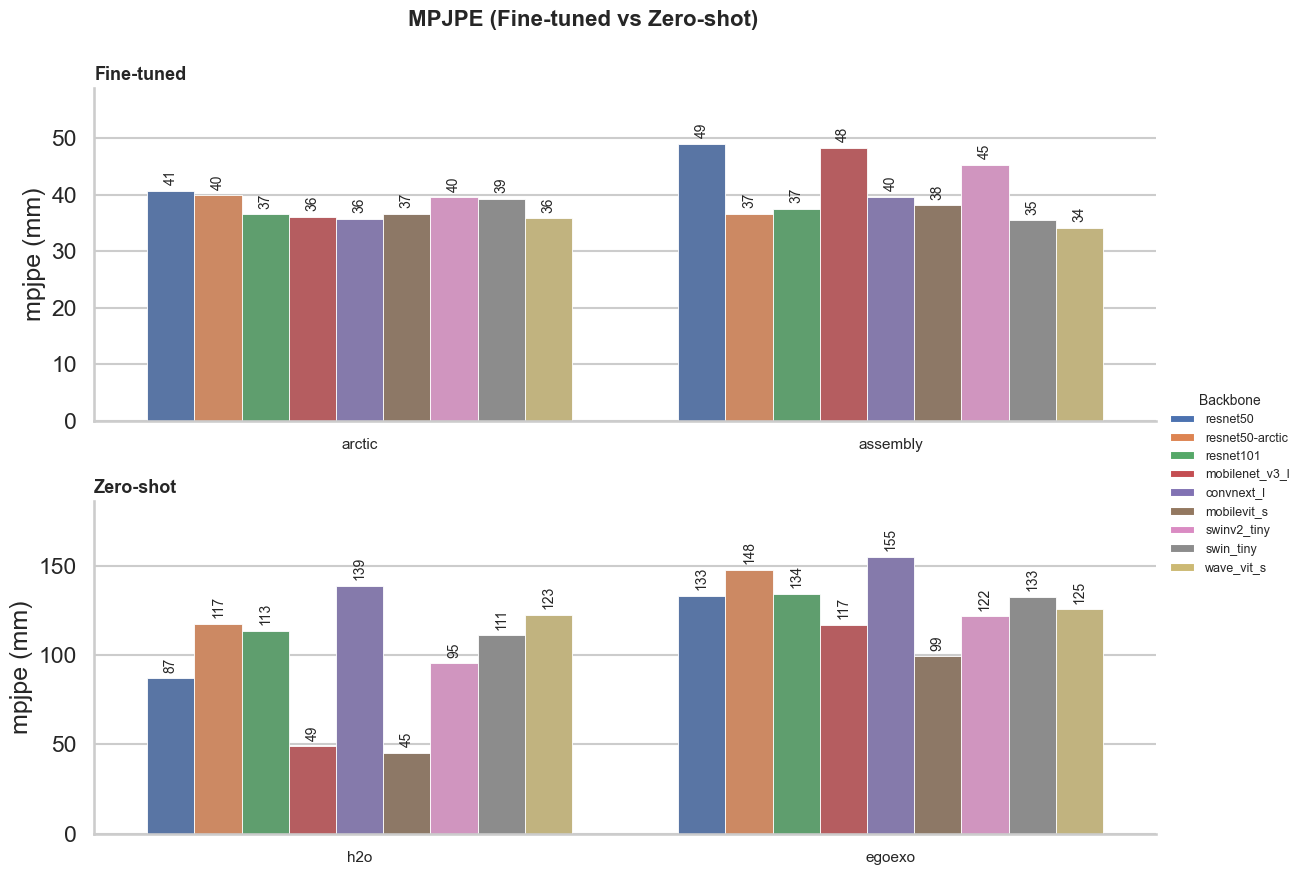

In [238]:
plot_in_vs_zeroshot("mpjpe")

## MRRPE

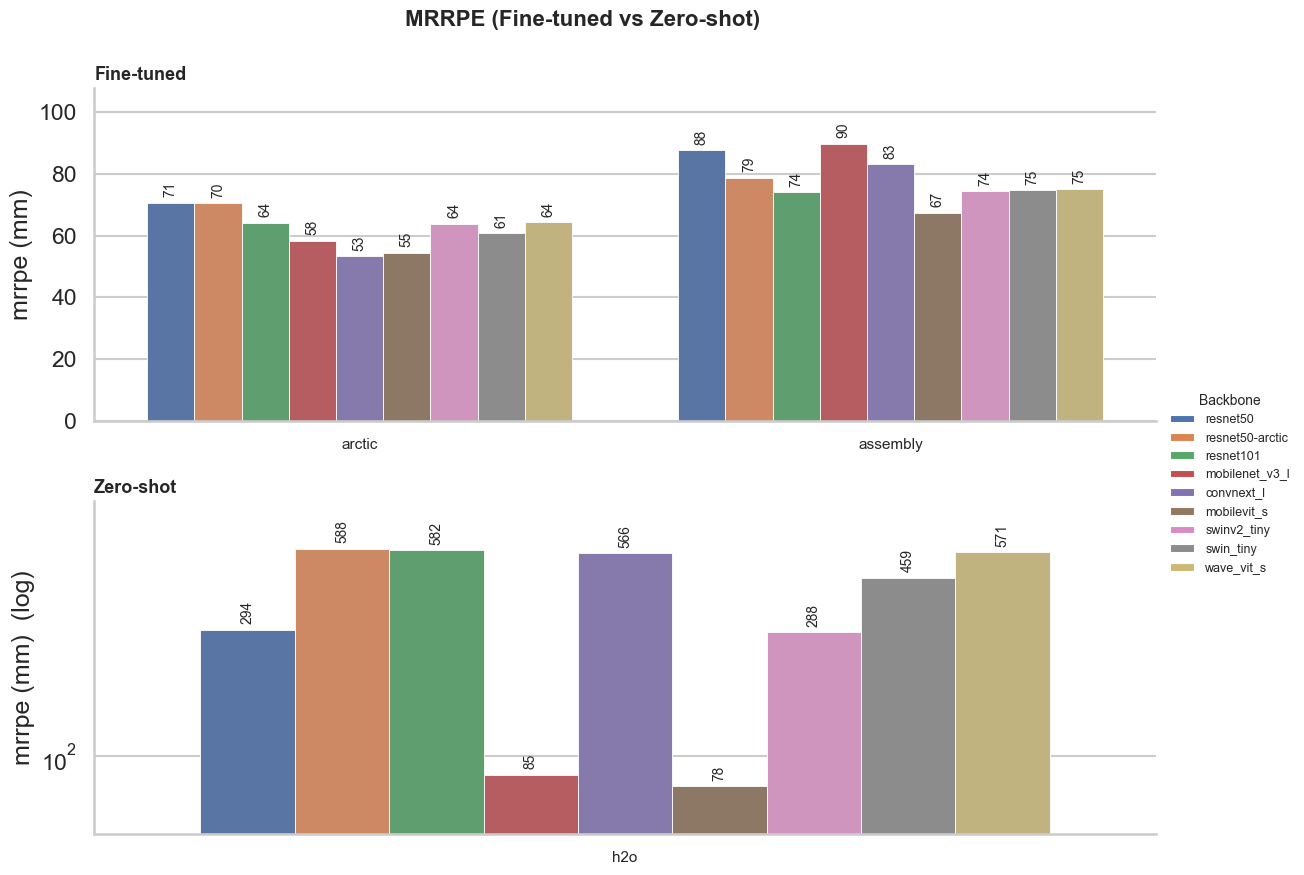

In [239]:
plot_in_vs_zeroshot("mrrpe", log_zero=True)

## Pixel error

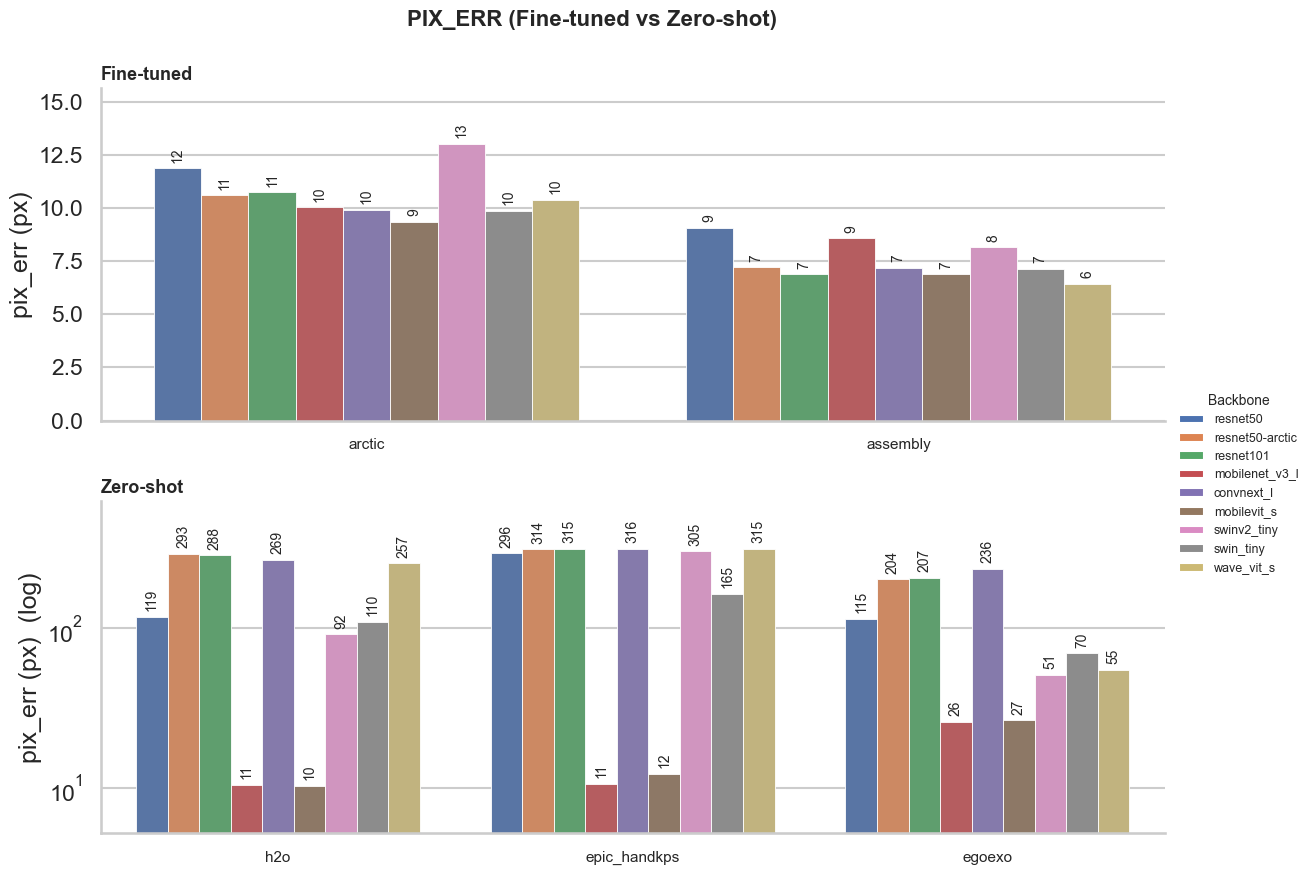

In [240]:
plot_in_vs_zeroshot("pix_err", log_zero=True)